In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy
from patsy import dmatrix
import seaborn as sn
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [8, 6]

# Problem 1

## Data Import & Preprocess

In [2]:
ir = pd.read_csv('IR.csv', index_col=0)
ir.index = pd.to_datetime(ir.index).year
unem = pd.read_csv('Unemployment.csv', index_col=0)
rep = pd.read_csv('Repossession.csv', index_col=0)
# merge data
df = pd.merge(ir, unem, left_index=True, right_index=True)
df = pd.merge(df, rep, left_index=True, right_index=True)
df.index.name = 'year'
df.columns = ['ir', 'unem', 'num_mort', 'num_pos']
for idx in df.index:  # convert data type
    df.loc[idx, 'num_mort'] = float(''.join(
        [s for s in df.loc[idx, 'num_mort'] if s != ',']))
    df.loc[idx, 'num_pos'] = float(''.join(
        [s for s in df.loc[idx, 'num_pos'] if s != ',']))
df = df.astype('float')
df['rep'] = df['num_pos'] / df['num_mort'] * 100  # unit: %
df.drop(['num_mort', 'num_pos'], axis=1, inplace=True)
del ir, unem, rep
df.head(3)

,ir,unem,rep
year,,,
1975,11.0000,4.5,0.095942
1976,11.1137,5.4,0.093010
1977,8.8772,5.6,0.083841


In [3]:
df.tail(3)

,ir,unem,rep
year,,,
2011,0.5,8.1,0.327653
2012,0.5,8.0,0.300425
2013,0.5,7.6,0.258359


## Data Cleaning & Visualization

In [4]:
# no missing value
# no extreme value
up = df['rep'].mean() + 3 * df['rep'].std()
low = df['rep'].mean() - 3 * df['rep'].std()
for row in df.index:
    if df.loc[row, 'rep'] >= up or df.loc[row, 'rep'] <= low:
        df.drop(row, inplace=True)
        print(row)

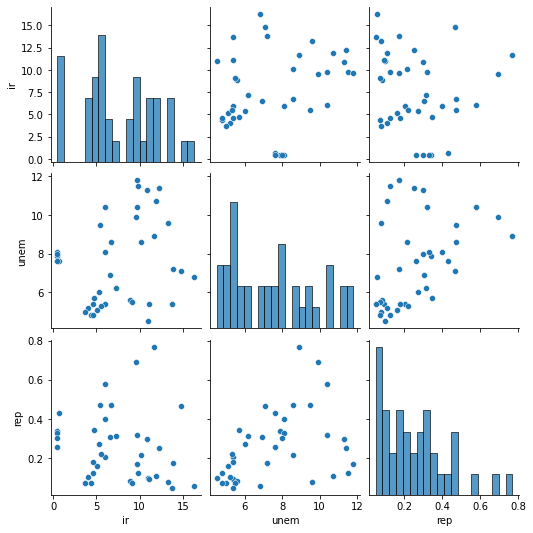

In [5]:
sn.pairplot(df, diag_kws={'bins': 20})
plt.savefig('figs/pairplot.png')
plt.show()

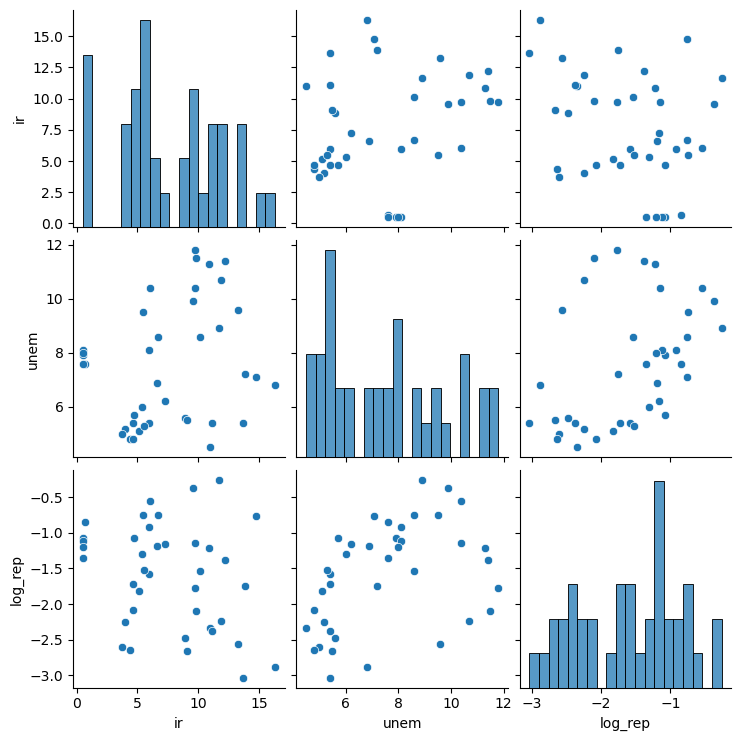

In [5]:
# we should log transform 'rep'
df['log_rep'] = np.log(df['rep'])
df.drop('rep', axis=1, inplace=True)
sn.pairplot(df, diag_kws={'bins': 20})
plt.show()

In [7]:
df.head()

,ir,unem,log_rep
year,,,
1975,11.0000,4.5,-2.344015
1976,11.1137,5.4,-2.375047
1977,8.8772,5.6,-2.478834
1978,9.1059,5.5,-2.658582
1979,13.6863,5.4,-3.035812


## Regression

### First Regression

In [7]:
# simple linear regression
for y_name in df.columns:
    y = df[y_name]
    X = df.drop(y_name, axis=1)
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     ir   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     5.816
Date:                Tue, 15 Nov 2022   Prob (F-statistic):            0.00648
Time:                        13:30:36   Log-Likelihood:                -106.17
No. Observations:                  39   AIC:                             218.3
Df Residuals:                      36   BIC:                             223.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1892      3.279     -0.973      0.3

### Simple Regression

In [8]:
y = df['log_rep']
X = df.drop('log_rep', axis=1)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rep   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     9.202
Date:                Tue, 15 Nov 2022   Prob (F-statistic):           0.000592
Time:                        13:30:36   Log-Likelihood:                -34.901
No. Observations:                  39   AIC:                             75.80
Df Residuals:                      36   BIC:                             80.79
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3477      0.364     -6.454      0.0

### Polynomial Regression

In [8]:
y = df['log_rep']
X = df.drop('log_rep', axis=1)
X['unem2'] = X['unem']**2

# ir_order = 2
# for i in range(2, ir_order + 1):
#     X['ir' + str(i)] = X['ir']**i
# tmp = X[['ir'] + ['ir' + str(i) for i in range(2, ir_order + 1)]]
# Q, _ = np.linalg.qr(tmp)
# X['ir'] = Q[:, 0]
# for i in range(2, unem_order + 1):
#     X['ir' + str(i)] = Q[:, i - 1]

# unem_order = 2
# for i in range(2, unem_order + 1):
#     X['unem' + str(i)] = X['unem']**i
# tmp = X[['unem'] + ['unem' + str(i) for i in range(2, unem_order + 1)]]
# Q, _ = np.linalg.qr(tmp)
# X['unem'] = Q[:, 0]
# for i in range(2, unem_order + 1):
#     X['unem' + str(i)] = Q[:, i - 1]

# all_features = df.drop('unem', axis=1)
# n = 2  # max polynomial order >= 2

# for ir_order in range(n + 1):
#     for rep_order in range(n + 1 - ir_order):
#         if ir_order + rep_order <= 1:
#             continue
#         else:
#             all_features['ir_' + str(ir_order) + '_rep_' +
#                          str(rep_order)] = all_features[
#                              'ir']**ir_order * all_features['rep']**rep_order

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rep   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     11.55
Date:                Wed, 07 Dec 2022   Prob (F-statistic):           2.05e-05
Time:                        08:56:54   Log-Likelihood:                -29.533
No. Observations:                  39   AIC:                             67.07
Df Residuals:                      35   BIC:                             73.72
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5791      1.311     -5.020      0.0

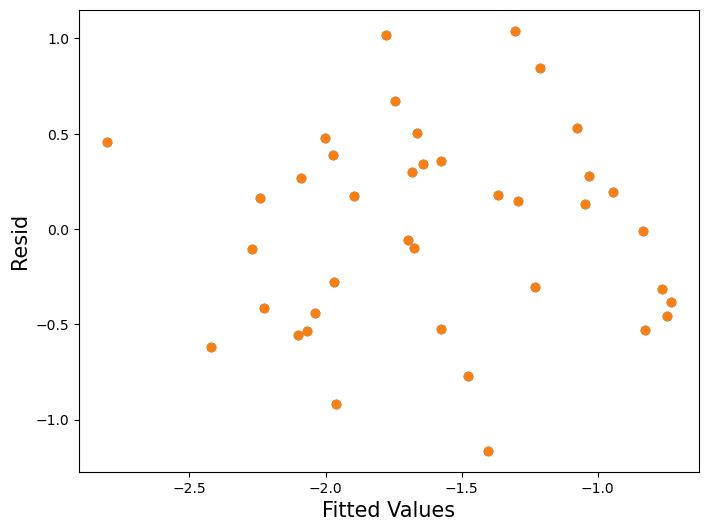

In [10]:
plt.scatter(model.fittedvalues, model.resid)
plt.xlabel('Fitted Values', fontsize=15)
plt.ylabel('Resid', fontsize=15)
#plt.savefig('figs/resid.png')
plt.show()

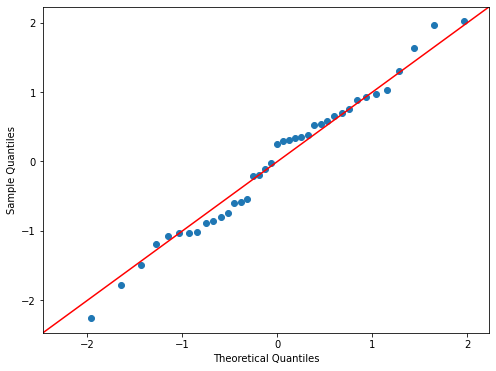

In [11]:
sm.qqplot(model.resid, fit=True, line='45')
plt.savefig('figs/qqplot.png')
plt.show()

### Splines Regression

In [12]:
# y = df['log_rep']
X = df.drop(['log_rep'], axis=1)

unem_df = 3
unem = {'unem': X['unem']}
unem_ns = np.asarray(dmatrix('cr(unem, df=' + str(unem_df) + ') - 1', unem))
X.drop('unem', axis=1, inplace=True)
for i in range(1, unem_df + 1):
    X['unem' + str(i)] = unem_ns[:, i - 1]
    
ir_df = 3
ir = {'ir': X['ir']}
ir_ns = np.asarray(dmatrix('cr(ir, df=' + str(ir_df) + ') - 1', ir))
X.drop('ir', axis=1, inplace=True)
for i in range(1, ir_df + 1):
    X['ir' + str(i)] = ir_ns[:, i - 1]
    
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rep   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     12.30
Date:                Tue, 15 Nov 2022   Prob (F-statistic):           2.73e-06
Time:                        13:30:36   Log-Likelihood:                -25.502
No. Observations:                  39   AIC:                             61.00
Df Residuals:                      34   BIC:                             69.32
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3312      0.103    -12.889      0.0

## After Normalization

In [13]:
df_norm = df.copy()
mean_std_rec = dict()
for col in df_norm.columns:
    mean_std_rec[col + '_mean'] = df_norm[col].mean()
    mean_std_rec[col + '_std'] = df_norm[col].std()
    df_norm[col] = (df_norm[col] - df_norm[col].mean()) / df_norm[col].std()
df_norm.head()

,ir,unem,log_rep
year,,,
1975,0.793932,-1.349180,-1.009403
1976,0.820434,-0.946833,-1.051485
1977,0.299128,-0.857423,-1.192228
1978,0.352436,-0.902128,-1.435978
1979,1.420081,-0.946833,-1.947529


In [14]:
# polynomial regression
y = df_norm['log_rep']
X = df_norm.drop('log_rep', axis=1)
X['unem2'] = X['unem']**2
X['unem2'] = (X['unem2'] - X['unem2'].mean()) / X['unem2'].std()

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                log_rep   R-squared (uncentered):                   0.498
Model:                            OLS   Adj. R-squared (uncentered):              0.456
Method:                 Least Squares   F-statistic:                              11.88
Date:                Tue, 15 Nov 2022   Prob (F-statistic):                    1.47e-05
Time:                        13:30:36   Log-Likelihood:                         -41.412
No. Observations:                  39   AIC:                                      88.82
Df Residuals:                      36   BIC:                                      93.82
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# Problem 2

## (a)

In [12]:
df_WLS = pd.read_csv('Python_DataQ2.csv', index_col=0)

X = df_WLS['x']
y = df_WLS['y_data']
X = sm.add_constant(X)
model_OLS = sm.OLS(y, X).fit()
print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                 y_data   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     347.7
Date:                Wed, 07 Dec 2022   Prob (F-statistic):           1.25e-23
Time:                        10:50:05   Log-Likelihood:                -68.470
No. Observations:                  50   AIC:                             140.9
Df Residuals:                      48   BIC:                             144.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2426      0.271     19.370      0.0

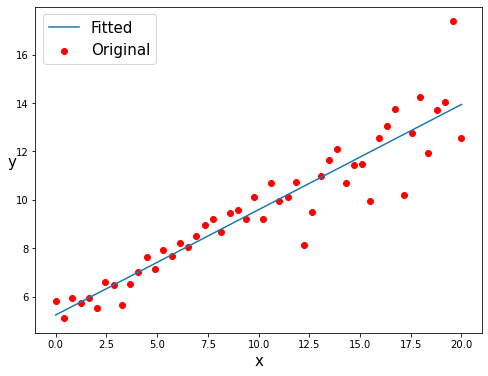

In [16]:
plt.plot(X['x'], model_OLS.fittedvalues, label='Fitted')
plt.scatter(X['x'], y, label='Original', color='r')
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15, rotation=0)
plt.legend(fontsize=15)
plt.savefig('figs Q2/a1.png')
plt.show()

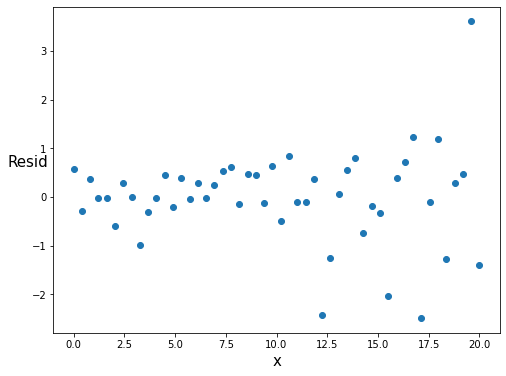

In [17]:
plt.scatter(X['x'], model_OLS.resid)
plt.xlabel('x', fontsize=15)
plt.ylabel('Resid', fontsize=15, rotation=0)
plt.savefig('figs Q2/a2.png')
plt.show()

## (b)

In [18]:
X = df_WLS['x']
y = df_WLS['y_data']
weights = 1 / df_WLS['weights']**2
X = sm.add_constant(X)
model_WLS = sm.WLS(y, X, weights=weights).fit()
print(model_WLS.summary())

                            WLS Regression Results                            
Dep. Variable:                 y_data   R-squared:                       0.927
Model:                            WLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     613.2
Date:                Tue, 15 Nov 2022   Prob (F-statistic):           5.44e-29
Time:                        13:30:36   Log-Likelihood:                -51.136
No. Observations:                  50   AIC:                             106.3
Df Residuals:                      48   BIC:                             110.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2469      0.143     36.790      0.0

In [19]:
model_OLS.params

const    5.242561
x        0.434869
dtype: float64

In [20]:
model_OLS.bse

const    0.270653
x        0.023321
dtype: float64

In [21]:
model_WLS.params

const    5.246855
x        0.446582
dtype: float64

In [22]:
model_WLS.bse

const    0.142615
x        0.018034
dtype: float64

## (c)

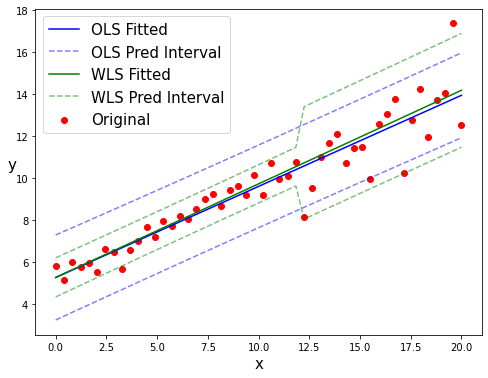

In [23]:
plt.plot(X['x'], model_OLS.fittedvalues, label='OLS Fitted', color='b')
plt.plot(X['x'],
         model_OLS.get_prediction().summary_frame()['obs_ci_upper'],
         label='OLS Pred Interval',
         color='b',
         linestyle='--',
         alpha=0.5)
plt.plot(X['x'],
         model_OLS.get_prediction().summary_frame()['obs_ci_lower'],
         color='b',
         linestyle='--',
         alpha=0.5)
plt.plot(X['x'], model_WLS.fittedvalues, label='WLS Fitted', color='g')
plt.plot(X['x'],
         model_WLS.get_prediction().summary_frame()['obs_ci_upper'],
         label='WLS Pred Interval',
         color='g',
         linestyle='--',
         alpha=0.5)
plt.plot(X['x'],
         model_WLS.get_prediction().summary_frame()['obs_ci_lower'],
         color='g',
         linestyle='--',
         alpha=0.5)
plt.scatter(X['x'], y, label='Original', color='r')
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15, rotation=0)
plt.legend(fontsize=15)
plt.savefig('figs Q2/c.png')
plt.show()

# Problem 3

In [24]:
def OptimalSpline(y, x):
    '''
    Try to find the optimal spline approximation.
    '''
    def pielinear(x, knots, p=3):
        '''
        x: observations x_i
        knots: knots k_i
        p: max order of the polynomial (assume to be 3)
        '''

        res = np.vander(x, p + 1, increasing=True)
        nullArray = np.zeros([len(x), 1])
        x_T = x.reshape(len(x), 1)
        for k in knots:
            res = np.concatenate([res, (np.maximum(x_T - k, nullArray))**p],
                                 axis=1)
        return res

    x = x.copy()
    y = y.copy()
    best_num_knots = -np.infty
    best_AIC = np.infty
    for num_knots in range(int(np.ceil(np.sqrt(len(x)))) + 1):
        if num_knots == 0:
            x_reg = np.vander(x, 4, increasing=True)
        else:
            knots = [
                np.percentile(x, 100 / (num_knots + 1)) * i
                for i in range(1, num_knots + 1)
            ]
            x_reg = pielinear(x, knots)
        model = sm.OLS(y, x_reg).fit()
        # all coefficients should be significant
        if (model.pvalues <= 0.05).all() and model.aic < best_AIC:
            best_AIC = model.aic
            best_num_knots = num_knots
    return best_num_knots

In [25]:
x = np.linspace(0, 10, 100)
y = x**3 + x**2 + x + 1
OptimalSpline(y, x)

0